Importación de librerías y configuración del entorno

In [ ]:
import sys
from pathlib import Path
import os

# Permitir que el notebook acceda a los scripts de la carpeta 'src'
notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Importar herramientas estándar y de Machine Learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score

# Desactivar los mensajes repetitivos de Optuna para mantener limpio el notebook
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Librerías cargadas con éxito.")

C:\Users\igo19\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas con éxito.


Carga de datos limpios y separados

In [3]:
from src.data_preprocessing import load_and_preprocess_data

# Cargamos el split oficial de entrenamiento y prueba
X_train, X_test, y_train, y_test = load_and_preprocess_data()

print(f"Datos listos para el entrenamiento supervisado:")
print(f"Conjunto de Entrenamiento (Train): X={X_train.shape}, y={y_train.shape}")
print(f"Conjunto de Prueba (Test): X={X_test.shape}, y={y_test.shape}")

Datos listos para el entrenamiento supervisado:
Conjunto de Entrenamiento (Train): X=(5634, 30), y=(5634,)
Conjunto de Prueba (Test): X=(1409, 30), y=(1409,)


Definición del objetivo de Optuna

In [4]:
def objective(trial):
    # 1. Optuna sugiere qué modelo entrenar en este ensayo
    classifier_name = trial.suggest_categorical("classifier", ["RandomForest", "LogisticRegression"])
    
    if classifier_name == "RandomForest":
        # Sugerir hiperparámetros para Random Forest
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 200, step=50)
        max_depth = trial.suggest_int("rf_max_depth", 5, 20)
        min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10)
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
            n_jobs=-1
        )
        
    else:
        # Sugerir hiperparámetros para Regresión Logística
        C = trial.suggest_float("lr_C", 1e-4, 10.0, log=True)
        solver = trial.suggest_categorical("lr_solver", ["lbfgs", "liblinear"])
        
        model = LogisticRegression(
            C=C,
            solver=solver,
            max_iter=1000,
            random_state=42
        )
    
    # 2. Aplicar Validación Cruzada (3 Folds) según lo solicitado por el profesor
    # Usamos f1_score como métrica de optimización
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    
    # Retornamos el promedio del F1-Score obtenido en los 3 folds
    return score.mean()

# Crear y ejecutar el estudio de Optuna
study = optuna.create_study(direction="maximize")
print("Iniciando búsqueda de hiperparámetros con Optuna (Simulando 24 entrenamientos totales)...")
study.optimize(objective, n_trials=12) # 12 trials * 3 folds = 36 entrenamientos en total

print("\n¡Optimización Completada!")
print(f"Mejor F1-Score en Validación Cruzada: {study.best_value:.4f}")
print("Mejores parámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

Iniciando búsqueda de hiperparámetros con Optuna (Simulando 24 entrenamientos totales)...

¡Optimización Completada!
Mejor F1-Score en Validación Cruzada: 0.5906
Mejores parámetros encontrados:
  - classifier: LogisticRegression
  - lr_C: 6.509016387098572
  - lr_solver: lbfgs


Entrenamiento definitivo con el total de datos de Train

In [5]:
# Extract los mejores resultados
best_params = study.best_params
best_model_name = best_params["classifier"]

print(f"Instanciando el mejor modelo encontrado: {best_model_name}")

if best_model_name == "RandomForest":
    final_model = RandomForestClassifier(
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        min_samples_split=best_params["rf_min_samples_split"],
        random_state=42,
        n_jobs=-1
    )
else:
    final_model = LogisticRegression(
        C=best_params["lr_C"],
        solver=best_params["lr_solver"],
        max_iter=1000,
        random_state=42
    )

# Entrenar el modelo final con todo el conjunto de entrenamiento estructurado
final_model.fit(X_train, y_train)
print("Modelo final entrenado exitosamente.")

Instanciando el mejor modelo encontrado: LogisticRegression
Modelo final entrenado exitosamente.


Evaluación de Desempeño en el Conjunto de Test

=== REPORTE DE CLASIFICACIÓN (CONJUNTO DE TEST) ===
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



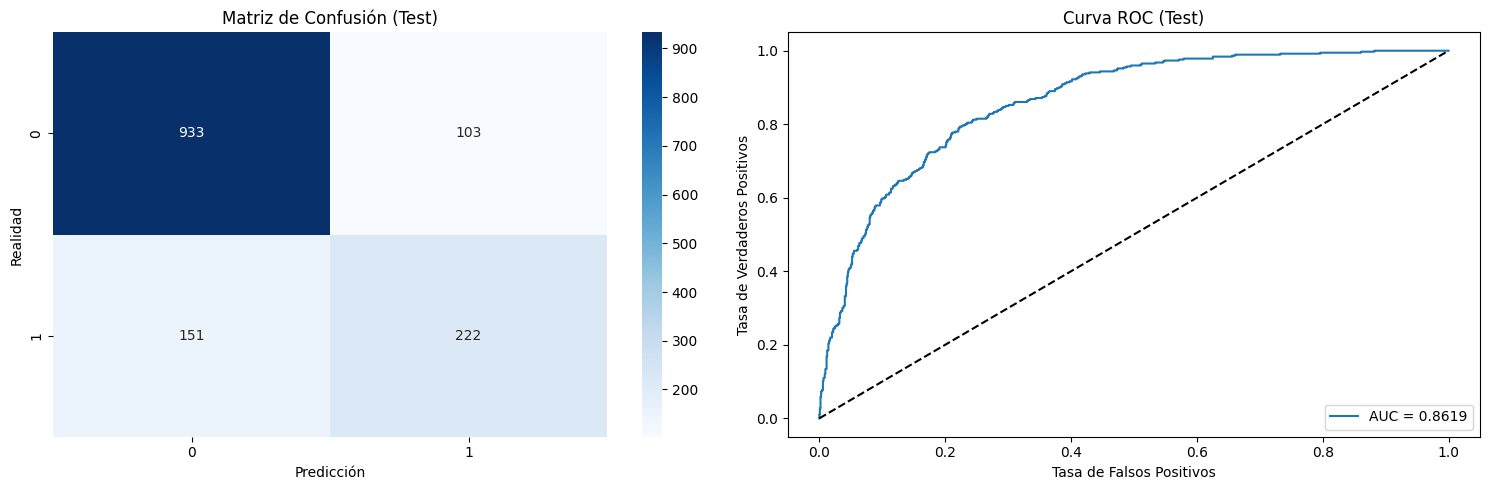

In [6]:
# 1. Realizar predicciones en el conjunto de Test de control
y_pred = final_model.predict(X_test)
y_probs = final_model.predict_proba(X_test)[:, 1]

# 2. Imprimir informe técnico de clasificación
print("=== REPORTE DE CLASIFICACIÓN (CONJUNTO DE TEST) ===")
print(classification_report(y_test, y_pred))

# 3. Graficar Matriz de Confusión y Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusión (Test)')
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Curva ROC (Test)')
ax[1].set_xlabel('Tasa de Falsos Positivos')
ax[1].set_ylabel('Tasa de Verdaderos Positivos')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()